In [1]:
!pip install trl>=0.15.0 transformers>=4.46.0 accelerate>=1.0.0 \
    peft>=0.14.0 bitsandbytes>=0.45.0 datasets>=3.0.0 \
    fastapi uvicorn pydantic>=2.0 httpx matplotlib
!pip install git+https://github.com/hs-zz27/incident-commander-openenv.git


  Cloning https://github.com/hs-zz27/incident-commander-openenv.git to /tmp/pip-req-build-ehsqzfg2
  Running command git clone --filter=blob:none --quiet https://github.com/hs-zz27/incident-commander-openenv.git /tmp/pip-req-build-ehsqzfg2
  Resolved https://github.com/hs-zz27/incident-commander-openenv.git to commit 97b5a9d9ca8d8a18d74d3f29c6511881addcaa8a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch, sys
print(f"Python {sys.version}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Python 3.10.8 (main, Nov 24 2022, 14:13:03) [GCC 11.2.0]
CUDA: True
GPU: NVIDIA L40S
VRAM: 47.7 GB


In [3]:
import os
!git clone https://github.com/hs-zz27/incident-commander-openenv.git repo
os.chdir("repo")
!pip install -e ".[train]" -q


Cloning into 'repo'...
remote: Enumerating objects: 495, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 495 (delta 88), reused 106 (delta 43), pack-reused 325 (from 1)
Receiving objects: 100% (495/495), 1.22 MiB | 34.77 MiB/s, done.
Resolving deltas: 100% (268/268), done.


In [4]:
from server.environment import IncidentCommanderEnvironment
from server.models import IncidentAction, ActionType

env = IncidentCommanderEnvironment()
obs = env.reset(task_name="cascading_failure", seed=42)
print(f"Health: {obs.system_health_score:.1%} | Severity: {obs.incident_severity.value}")
for name, svc in sorted(obs.services.items()):
    emoji = "🟢" if svc.status.value=="healthy" else ("🟡" if svc.status.value=="degraded" else "🔴")
    print(f"  {emoji} {name:12s} {svc.status.value}")


Health: 28.1% | Severity: critical
  🟡 auth         degraded
  🟢 cache        healthy
  🔴 checkout     down
  🟡 database     degraded
  🟢 notification healthy
  🟡 payments     degraded


In [5]:
obs = env.step(IncidentAction(action_type=ActionType.INSPECT_LOGS, service_name="database"))
print(f"reward={obs.reward:.4f} | health={obs.system_health_score:.1%}")
print(f"Log: {obs.logs[0] if obs.logs else 'none'}")
env.close()


reward=0.0450 | health=28.1%
Log: [2026-04-03T10:01:03Z] ERROR database: Slow query detected: SELECT * FROM transactions — 8200ms.


In [6]:
from train_grpo import build_obs_prompt
env = IncidentCommanderEnvironment()
obs = env.reset(task_name="single_service_failure", seed=42)
print(build_obs_prompt(obs.model_dump(), step=1, action_history=[]))
env.close()


You are an SRE Incident Commander. Diagnose and fix the following incident.
Step 1/15
System Health: 55.30%
Severity: critical
Escalation Tier: 1/4

Services:
  🟡 auth: degraded | err=40.0% | lat=2500ms | cpu=65% | ver=v1.0.0
  🔴 cache: down | err=100.0% | lat=0ms | cpu=0% | ver=v1.0.0
  🟡 checkout: degraded | err=30.0% | lat=3000ms | cpu=55% | ver=v1.0.0
  🟢 database: healthy | err=1.0% | lat=20ms | cpu=12% | ver=v1.0.0
  🟢 notification: healthy | err=1.0% | lat=30ms | cpu=10% | ver=v1.0.0
  🟢 payments: healthy | err=2.0% | lat=40ms | cpu=18% | ver=v1.0.0

Alerts:
  🔴 CRITICAL: cache is DOWN — all instances unreachable.
  🟡 WARNING: auth is DEGRADED — error rate 40.0%, latency 2500ms.
  🟡 WARNING: checkout is DEGRADED — error rate 30.0%, latency 3000ms.

Valid action_type values: inspect_logs, inspect_metrics, restart_service, scale_service, rollback, clear_cache, escalate, do_nothing
Valid service_name values: auth, cache, checkout, database, notification, payments

Respond with ONLY

In [12]:
!python sft_warmstart.py --generate-only --output-dir sft_data_1p5b


  SFT Warm-Start — Incident Commander RL Pipeline
  Base model:  Qwen/Qwen2.5-0.5B-Instruct
  Tasks:       5 (single_service_failure, cascading_failure, hidden_root_cause, chaos_cascade, multi_root_cause)
  Seeds/task:  5
  Strategies:  expert + heuristic + recovery + diverse

Phase 1: Generating expert/heuristic trajectories...

  ── Dataset Statistics ──
  Total pairs: 570
    cascading_failure: 140 pairs  (episode_score=0.885)
    chaos_cascade: 130 pairs  (episode_score=0.909)
    hidden_root_cause: 75 pairs  (episode_score=0.887)
    multi_root_cause: 165 pairs  (episode_score=0.846)
    single_service_failure: 60 pairs  (episode_score=0.856)
    diverse: 150 pairs
    expert: 140 pairs
    heuristic: 145 pairs
    recovery: 135 pairs

  Action distribution in training data:
    restart_service: 260 (46%)
    inspect_logs: 130 (23%)
    rollback: 40 (7%)
    scale_service: 40 (7%)
    clear_cache: 40 (7%)
    write_runbook: 30 (5%)
    inspect_metrics: 30 (5%)

  Per-step reward: 

In [16]:
import json, glob, os

# Find the dataset file wherever it was saved
candidates = glob.glob("sft_data_1p5b/**/*.json", recursive=True) + \
             glob.glob("sft_data_1p5b/*.json")
print("Files found:", candidates)

# Pick the right one
ds_path = next((p for p in candidates if "dataset" in p or "sft" in p), candidates[0] if candidates else None)

if ds_path:
    with open(ds_path) as f:
        ds = json.load(f)
    print(f"Size: {len(ds)} samples")
    print(f"Keys in sample: {list(ds[0].keys())}")
    print(f"Example response: {ds[0].get('response', ds[0].get('completion', '?'))}")
else:
    # Dataset not yet generated - generate inline
    print("No dataset found - generating now...")
    os.system("python sft_warmstart.py --generate-only --output-dir sft_data_1p5b")
    candidates = glob.glob("sft_data_1p5b/*.json")
    print("Generated:", candidates)


Files found: []
No dataset found - generating now...
  SFT Warm-Start — Incident Commander RL Pipeline
  Base model:  Qwen/Qwen2.5-0.5B-Instruct
  Tasks:       5 (single_service_failure, cascading_failure, hidden_root_cause, chaos_cascade, multi_root_cause)
  Seeds/task:  5
  Strategies:  expert + heuristic + recovery + diverse

Phase 1: Generating expert/heuristic trajectories...

  ── Dataset Statistics ──
  Total pairs: 570
    cascading_failure: 140 pairs  (episode_score=0.885)
    chaos_cascade: 130 pairs  (episode_score=0.909)
    hidden_root_cause: 75 pairs  (episode_score=0.887)
    multi_root_cause: 165 pairs  (episode_score=0.846)
    single_service_failure: 60 pairs  (episode_score=0.856)
    diverse: 150 pairs
    expert: 140 pairs
    heuristic: 145 pairs
    recovery: 135 pairs

  Action distribution in training data:
    restart_service: 260 (46%)
    inspect_logs: 130 (23%)
    rollback: 40 (7%)
    scale_service: 40 (7%)
    clear_cache: 40 (7%)
    write_runbook: 30 (

In [17]:
import os
print(os.path.exists("results/sft_dataset.json"))  # should be True


True


In [18]:
!python sft_warmstart.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --epochs 2 \
    --batch-size 4 \
    --lr 2e-5 \
    --num-seeds 8 \
    --use-lora \
    --gradient-checkpointing \
    --output-dir sft_adapter_1p5b \
    --merged-output-dir sft_merged_1p5b


  SFT Warm-Start — Incident Commander RL Pipeline
  Base model:  Qwen/Qwen2.5-1.5B-Instruct
  Tasks:       5 (single_service_failure, cascading_failure, hidden_root_cause, chaos_cascade, multi_root_cause)
  Seeds/task:  8
  Strategies:  expert + heuristic + recovery + diverse

Phase 1: Generating expert/heuristic trajectories...

  ── Dataset Statistics ──
  Total pairs: 912
    cascading_failure: 224 pairs  (episode_score=0.885)
    chaos_cascade: 208 pairs  (episode_score=0.909)
    hidden_root_cause: 120 pairs  (episode_score=0.887)
    multi_root_cause: 264 pairs  (episode_score=0.846)
    single_service_failure: 96 pairs  (episode_score=0.856)
    diverse: 240 pairs
    expert: 224 pairs
    heuristic: 232 pairs
    recovery: 216 pairs

  Action distribution in training data:
    restart_service: 416 (46%)
    inspect_logs: 208 (23%)
    rollback: 64 (7%)
    scale_service: 64 (7%)
    clear_cache: 64 (7%)
    inspect_metrics: 48 (5%)
    write_runbook: 48 (5%)

  Per-step reward:

In [20]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch, json

tok = AutoTokenizer.from_pretrained("sft_merged_1p5b")
mdl = AutoModelForCausalLM.from_pretrained(
    "sft_merged_1p5b",
    dtype=torch.bfloat16,   # fixed: dtype not torch_dtype
    device_map="auto"
)

from server.environment import IncidentCommanderEnvironment
from train_grpo import build_obs_prompt

env = IncidentCommanderEnvironment()
obs = env.reset(task_name="single_service_failure", seed=42)
prompt = build_obs_prompt(obs.model_dump(), 1, [])

# ── FIX: tokenize as a dict, pass **inputs to generate ──
inputs = tok.apply_chat_template(
    [{"role": "user", "content": prompt}],
    return_tensors="pt",
    add_generation_prompt=True,
    return_dict=True,   # ← returns {input_ids, attention_mask}
).to(mdl.device)

with torch.no_grad():
    out = mdl.generate(
        **inputs,                           # ← unpack the dict
        max_new_tokens=64,
        do_sample=False,
        pad_token_id=tok.pad_token_id,
    )

result = tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print(f"Output: {result}")
try:
    print(f"✅ Valid JSON: {json.loads(result)}")
except:
    print("❌ Invalid JSON")

env.close()
del mdl  # free VRAM before GRPO
torch.cuda.empty_cache()


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Output: {"action_type": "inspect_metrics", "service_name": "cache"}
✅ Valid JSON: {'action_type': 'inspect_metrics', 'service_name': 'cache'}


In [22]:
!python train_grpo.py \
    --model sft_merged_1p5b \
    --steps 300 \
    --batch-size 1 \
    --lr 2e-6 \
    --num-generations 16 \
    --num-seeds 8 \
    --use-lora \
    --gradient-checkpointing \
    --lora-r 32 \
    --lora-alpha 64 \
    --save-steps 25 \
    --log-every 10 \
    --reward-mode direct \
    --snapshot-steps "1,2,3,4,5,6,7,8" \
    --output-dir trained_model_1p5b


  GRPO Training — Incident Commander
  Model: sft_merged_1p5b
  Steps: 300
  per_device_batch: 16  grad_accum: 1  effective: 16
  Learning rate: 2e-06
  LoRA: enabled
  Gradient checkpointing: enabled
  Generations per prompt: 16
  Save every: 25 steps
GPU detected: NVIDIA L40S

Loading model: sft_merged_1p5b...
  Precision: bfloat16
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████| 338/338 [00:00<00:00, 635.42it/s]
  Gradient checkpointing: enabled
  LoRA: r=32, alpha=64, targets=['q_proj', 'v_proj', 'k_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
  Parameters: 1,543,714,304

Building training dataset (5 tasks × 8 seeds)...
  Dataset size: 280 samples
  Columns: ['prompt', 'task_name', 'seed', 'action_history']

Initializing GRPOTrainer...
[transformers] max_steps is given, it will override any value given in num_train_epochs

  Starting GRPO training for 300 steps...
  Training on 280 prompts with 16 generations e

In [23]:
!python evaluate_trained.py \
    --adapter trained_model_1p5b \
    --base-model sft_merged_1p5b \
    --episodes 3 \
    --verbose \
    --output results/eval.json


usage: evaluate_trained.py [-h] [--base-model BASE_MODEL] [--adapter ADAPTER]
                           [--device {auto,cpu,cuda,mps}] [--task TASK]
                           [--episodes EPISODES] [--verbose] [--no-model]
                           [--sample]
evaluate_trained.py: error: unrecognized arguments: --output results/eval.json


In [24]:
!python evaluate_trained.py \
    --adapter trained_model_1p5b \
    --base-model sft_merged_1p5b \
    --episodes 3 \
    --verbose


  POST-TRAINING EVALUATION — Trained LoRA vs All Baselines
  Tasks:    single_service_failure, cascading_failure, hidden_root_cause, chaos_cascade, multi_root_cause
  Episodes: 3 per agent per task
  Device:   cuda
  Adapter:  trained_model_1p5b
  Model:    sft_merged_1p5b
  Time:     2026-04-26 10:19:48

┌──────────────────────────────────────────────────────────────────────┐
│  EXPERT BASELINE (optimal action sequence, 1 run)                   │
└──────────────────────────────────────────────────────────────────────┘
  single_service_failure         0.8500  ✅
  cascading_failure              0.9000  ✅
  hidden_root_cause              0.8833  ✅
  chaos_cascade                  0.9167  ✅
  multi_root_cause               0.9000  ✅

┌──────────────────────────────────────────────────────────────────────┐
│  NAIVE BASELINE (restart everything, 1 run)                         │
└──────────────────────────────────────────────────────────────────────┘
  single_service_failure         0.8000  

In [25]:
import json
with open("results/evaluation_results.json") as f:
    res = json.load(f)

TASKS = ["single_service_failure","cascading_failure","hidden_root_cause","chaos_cascade","multi_root_cause"]
agents = ["expert","heuristic","naive","trained"]
print(f"{'Task':<26}" + "".join(f"{a:>14}" for a in agents))
print("-"*82)
totals = {a:0 for a in agents}
for t in TASKS:
    row = f"{t:<26}"
    for a in agents:
        d = res.get(a,{}).get(t,{})
        s = d.get("avg_score", d.get("score", 0))
        row += f"{s:>14.3f}"; totals[a] += s
    print(row)
print("-"*82)
print(f"{'AVERAGE':<26}" + "".join(f"{totals[a]/5:>14.3f}" for a in agents))


Task                              expert     heuristic         naive       trained
----------------------------------------------------------------------------------
single_service_failure             0.850         0.750         0.800         0.933
cascading_failure                  0.900         0.277         0.550         0.828
hidden_root_cause                  0.883         0.695         0.170         0.857
chaos_cascade                      0.917         0.394         0.767         0.846
multi_root_cause                   0.900         0.367         0.600         0.827
----------------------------------------------------------------------------------
AVERAGE                            0.890         0.497         0.577         0.858


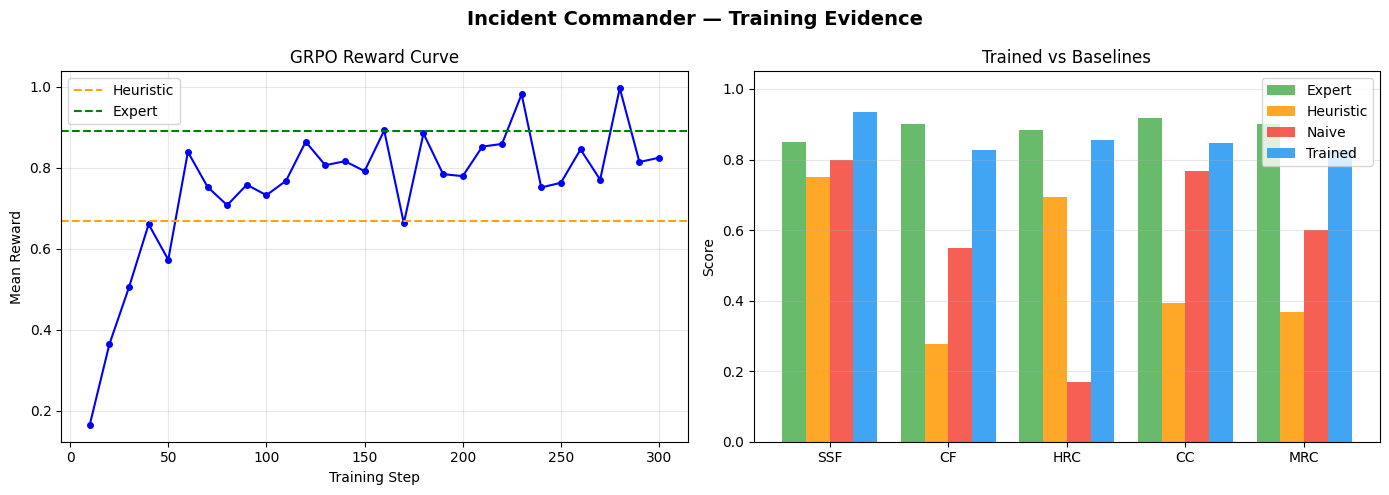

In [26]:
import matplotlib.pyplot as plt, json, os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Incident Commander — Training Evidence", fontsize=14, fontweight="bold")

# Reward curve from log_history
log = json.load(open("results/training_log.json")) if os.path.exists("results/training_log.json") else {}
history = log.get("log_history", []) if isinstance(log, dict) else []
steps = [h["step"] for h in history if "reward" in h]
rewards = [h["reward"] for h in history if "reward" in h]
if steps:
    axes[0].plot(steps, rewards, "b-o", markersize=4)
    axes[0].axhline(0.669, color="orange", linestyle="--", label="Heuristic")
    axes[0].axhline(0.890, color="green",  linestyle="--", label="Expert")
    axes[0].set_xlabel("Training Step"); axes[0].set_ylabel("Mean Reward")
    axes[0].set_title("GRPO Reward Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Baseline comparison
task_short = ["SSF","CF","HRC","CC","MRC"]
colors = {"expert":"#4CAF50","heuristic":"#FF9800","naive":"#f44336","trained":"#2196F3"}
w, x = 0.2, range(5)
for i, (ag, col) in enumerate(colors.items()):
    vals = [res.get(ag,{}).get(t,{}).get("avg_score", res.get(ag,{}).get(t,{}).get("score",0)) for t in TASKS]
    axes[1].bar([xi+(i-1.5)*w for xi in x], vals, w, label=ag.capitalize(), color=col, alpha=0.85)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(task_short)
axes[1].set_ylabel("Score"); axes[1].set_title("Trained vs Baselines")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/training_evidence.png", dpi=150, bbox_inches="tight")
plt.show()
